In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import fuzz, process
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split

### Load Data

In [3]:
main_directory = os.getenv("POND_PATH")
data_directory = os.getenv("POND_DATA_PATH")

In [4]:
# Directory
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)
registered_titles = [entry['title'] for entry in paper_info.values()]

# Original dataset
pond_data = pd.read_csv(os.path.join(data_directory, "pond_data.csv"), encoding_errors='ignore')
pond_data = pond_data.loc[pond_data.title.isin(registered_titles)]
pond_df = pond_data.loc[:,['author', 'title', 'pondname', 'location', 'author_term',
            'max_depth_m', 'mean_surfacearea_m2', 'macrophytes_percentcover', 'ph', 'tn_ugpl', 'tp_ugpl', 'chla_ugpl']]
pond_df.columns = ['author', 'title', 'name', 'location', 'ecosystem',
            'depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chl']

# Split the dataframe's rows so that each measurement is in its own row
pond_df = pond_df.melt(id_vars=['author', 'title', 'name', 'location', 'ecosystem'], 
                       value_vars=['depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chl'],
                       var_name='measurement', value_name='value')
pond_df = pond_df.dropna(subset=['value'])
pond_df = pond_df.reset_index(drop=True)
n_entries = pond_df.shape[0]

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [5]:
pond_df

,author,title,name,location,ecosystem,measurement,value
0,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor1,western poland,meteorite crater ponds,depth,1.0
1,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor2,western poland,meteorite crater ponds,depth,1.0
2,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor3,western poland,meteorite crater ponds,depth,0.3
3,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor4,western poland,meteorite crater ponds,depth,0.7
4,hanrahan,multivariate chemometrical classification and ...,lake tuendae,mojave desert; california; united states,aquatic environment,depth,1.7
...,...,...,...,...,...,...,...
3405,eskinazi-sant'anna; eneida maria; pace; michae...,the potential of the zooplankton resting-stage...,coutos,brazil,temporary lake/seasonal pond,chl,4.5
3406,eskinazi-sant'anna; eneida maria; pace; michae...,the potential of the zooplankton resting-stage...,seca,brazil,temporary lake,chl,8.2
3407,sepulveda-jauregui; armando; martinez-cruz; ka...,assessment of methane and carbon dioxide emiss...,grosse fuchskuhle,mecklenburg-brandenburg lake district,small acidic bog lake,chl,8.0
3408,sepulveda-jauregui; armando; martinez-cruz; ka...,assessment of methane and carbon dioxide emiss...,grosse fuchskuhle ne,mecklenburg-brandenburg lake district,small acidic bog lake,chl,32.3


In [6]:
def process(
    result_df,
    conversion_table
):
    result_df = result_df.copy()

    # Drop rows without any measurements
    result_df = result_df.dropna(subset=['measurement'], how='all')

    # Convert units
    for row_idx, row in result_df.iterrows():
        measurement_type = row['measurement']
        val = row['value']
        unit = row['units']
        if conversion_table.get(measurement_type) is not None:
            if conversion_table[measurement_type].get(unit) is not None:
                conversion_factor = conversion_table[measurement_type][unit]
                result_df.at[row_idx, 'value'] = val * conversion_factor
            else:
                result_df.at[row_idx, 'value'] = np.nan # Units not recognized

    # Drop all unit columns
    result_df = result_df.drop(columns=["units"])

    # Drop exact duplicates
    result_df = result_df.drop_duplicates()

    # Reset index
    result_df = result_df.reset_index(drop=True)

    return result_df


conversion_table = {
    'depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1},
    'vegetation_cover': {"%": 0.01},
    'tn': {"mg/L": 1000, "µg/L": 1, "μmol/L": 14.01, "ppm": 1000, "ppb": 1},
    'tp': {"mg/L": 1000, "µg/L": 1, "μmol/L": 30.97, "ppm": 1000, "ppb": 1},
    'chl': {"mg/L": 1000, "µg/L": 1}
}

In [10]:
ignore_measurements = ['latitude', 'longitude'] # Ignoring these for now because they are not in the original dataset

result_df = pd.read_csv('../data/pond_results5.csv')
result_df = result_df.loc[~result_df.measurement.isin(ignore_measurements)]
result_df['value'] = result_df['value'].str.replace(',', '')  # Remove commas from numbers
result_df['value'] = pd.to_numeric(result_df['value'], errors='coerce')
result_df = process(result_df, conversion_table)

result_df_validated = pd.read_csv('../data/pond_results4_validated.csv')
result_df_validated = result_df_validated.loc[~result_df_validated.measurement.isin(ignore_measurements)]
result_df_validated['value'] = result_df_validated['value'].str.replace(',', '')  # Remove commas from numbers
result_df_validated['value'] = pd.to_numeric(result_df_validated['value'], errors='coerce')
result_df_validated = process(result_df_validated, conversion_table)

In [11]:
result_df

,title,author,year,chunk_id,context,name,date,location,ecosystem,measurement,...,parametric_l23,parametric_l24,parametric_l25,parametric_l26,parametric_l27,parametric_l28,parametric_l29,parametric_l30,parametric_l31,judgement
0,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,6,"standard, ponds are generally defined as small...",ponds,NaN,NaN,pond,surface_area,...,0.084815,0.122336,0.127263,0.125476,0.126107,0.104416,0.131608,0.135615,0.137686,True
1,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,11,## MATERIALS AND METHODS\n\n\n\n \n## Study Si...,temperate freshwater agricultural pond,"October 2016, November 2016, December 2016","central Maryland, United States",pond,surface_area,...,0.109854,0.097205,0.117755,0.120037,0.137995,0.128686,0.102209,0.138120,0.136724,True
2,aquatic insect assemblages of man-made permane...,fontanarrosa,2013,134,Sampling sites were located in one of the larg...,P3,NaN,Parques de Palermo,pond,surface_area,...,0.060000,0.061836,0.061015,0.060212,0.060110,0.059510,0.062137,0.062245,0.068599,False
3,aquatic insect assemblages of man-made permane...,fontanarrosa,2013,170,## Table 1 Main characteristics of four ponds ...,P1,January 2004,Buenos Aires city (Argentina),pond,surface_area,...,0.107229,0.125994,0.119300,0.109815,0.122642,0.122726,0.124400,0.129785,0.105002,True
4,aquatic insect assemblages of man-made permane...,fontanarrosa,2013,170,## Table 1 Main characteristics of four ponds ...,P2,January 2004,Buenos Aires city (Argentina),pond,surface_area,...,0.106840,0.111393,0.107288,0.106951,0.115616,0.116126,0.120875,0.124949,0.108435,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,6487,## Table 1. Mean ( ± SE) values of environment...,Santisteban,NaN,NaN,wetland,chla,...,0.114157,0.112915,0.119709,0.106113,0.122224,0.119293,0.084118,0.129860,0.138353,True
1470,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,6487,## Table 1. Mean ( ± SE) values of environment...,Castillo,NaN,NaN,wetland,chla,...,0.111595,0.110528,0.110865,0.105049,0.114723,0.118935,0.092474,0.127086,0.138145,True
1471,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,6487,## Table 1. Mean ( ± SE) values of environment...,Ardal,NaN,NaN,wetland,chla,...,0.123604,0.118350,0.110091,0.108255,0.118295,0.117645,0.089688,0.122132,0.138314,True
1472,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,6487,## Table 1. Mean ( ± SE) values of environment...,Quinta,NaN,NaN,wetland,chla,...,0.118030,0.113470,0.109845,0.106181,0.118548,0.114611,0.089881,0.120791,0.138321,True


### LLM as Judge Baseline

In [13]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 0,
    'deviation': 0,
}

y_judge = result_df_validated['judgement']
y_valid = result_df_validated['validation_status'].map(status_dict)

accuracy = (y_judge == y_valid).mean()
print(f"LLM Judge Accuracy: {accuracy:.4f}")

LLM Judge Accuracy: 0.6700


### Manually validated model

In [14]:
context_columns = []
context_columns_by_layer = [[] for _ in range(32)]
parametric_columns = []

for col in result_df_validated.columns:
    if col.startswith('context_'):
        context_columns.append(col)
        layer_num = int(col.split('_')[-1].split('h')[0][1:])
        context_columns_by_layer[layer_num].append(col)
    elif col.startswith('parametric_'):
        parametric_columns.append(col)

In [15]:
pond_results_aggregate = result_df_validated.drop(columns = context_columns)
context_columns_aggregate = []
for layer_num in range(32):
    cols = context_columns_by_layer[layer_num]
    pond_results_aggregate[f'context_l{layer_num}'] = result_df_validated[cols].mean(axis=1)
    context_columns_aggregate.append(f'context_l{layer_num}')

In [48]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 0,
    'deviation': 1,
}

X = result_df_validated[context_columns + parametric_columns]
y = result_df_validated['validation_status'].map(status_dict)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Fitting regularization parameter for sparse PCA
regularization_params = np.linspace(0.0, 0.1, 11)
scores = []

for alpha in regularization_params:
    spca = SparsePCA(n_components=2, alpha=alpha, random_state=42)
    spca.fit(X_train)
    X_reconstructed = spca.inverse_transform(spca.transform(X_train))
    score = np.linalg.norm(X_train - X_reconstructed) / X_train.shape[0]
    scores.append(score)

Text(0, 0.5, 'Reconstruction Error')

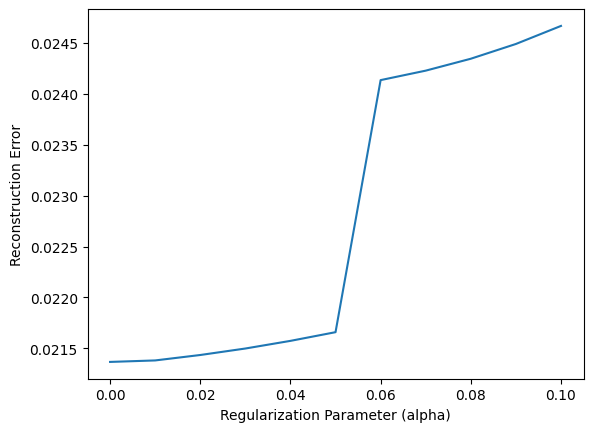

In [18]:
plt.plot(regularization_params, scores)
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Reconstruction Error')

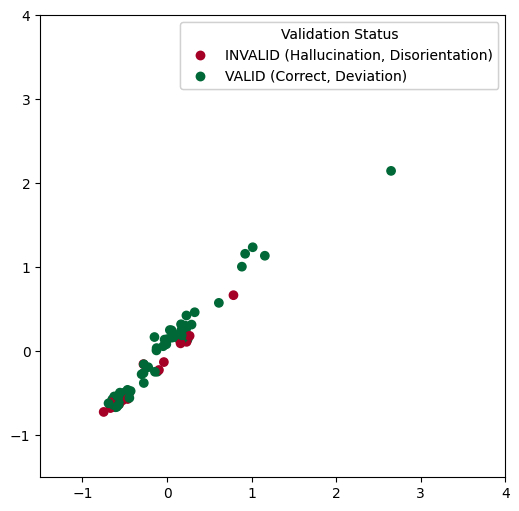

In [49]:
# Dimensionality reduction for visualization
pca = SparsePCA(n_components=2, alpha = 0.05, random_state=42)
X_reduced = pca.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(6,6), dpi = 100)
scatter = ax.scatter(X_reduced[:,0], X_reduced[:,1], c=y_train, cmap='RdYlGn')
legend1 = ax.legend(handles = scatter.legend_elements()[0], labels = ['INVALID (Hallucination, Disorientation)', 'VALID (Correct, Deviation)'],
                    loc="upper right", title="Validation Status")
ax.add_artist(legend1)
plt.xlim(-1.5,4)
plt.ylim(-1.5,4)
plt.show()

In [21]:
scatter.legend_elements()[0]

In [157]:
# Fitting regularization parameter for logistic regression
regularization_params = np.linspace(0.0, 0.001, 101)
scores = []

for alpha in regularization_params:
    model = LogisticRegression(C=1/(alpha + 1e-10), penalty = "l1", solver = "liblinear", max_iter=1000)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    scores.append(score)

Text(0, 0.5, 'Reconstruction Error')

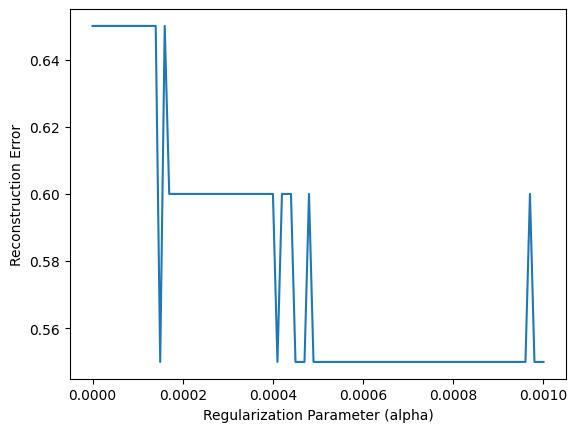

In [158]:
plt.plot(regularization_params, scores)
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Reconstruction Error')

In [35]:
# Fit logistic regression model
alpha = 0.0001
model = LogisticRegression(C = 1/(alpha + 1e-10), penalty = "l1", solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)
train_accuracy = model.score(X_train, y_train)
print(f"Logistic Regression Train Accuracy: {train_accuracy:.4f}")
accuracy = model.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {accuracy:.4f}")

coefficients = model.coef_[0]
context_coefficients = coefficients[:-32].reshape(32, 32)
parametric_coefficients = coefficients[-32:]

Logistic Regression Train Accuracy: 1.0000
Logistic Regression Test Accuracy: 0.6500


In [36]:
model.predict(X_test)

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [37]:
y_test

83    0
53    0
70    1
45    1
44    1
39    0
22    0
80    1
10    1
0     1
18    0
30    1
73    1
33    0
90    1
4     1
76    0
77    1
12    1
31    0
Name: validation_status, dtype: int64

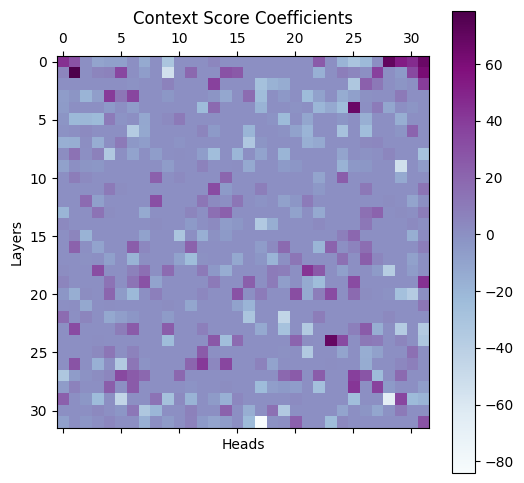

In [40]:
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)

Text(0.5, 0, 'Layers')

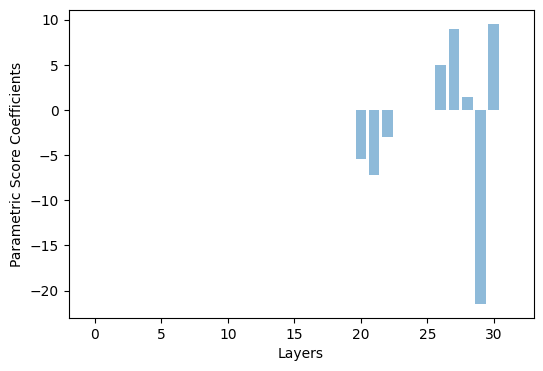

In [41]:
fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')

### Matching to dataset

In [63]:
def match_datapoints(ground_truth, extracted):
    matching = {}
    for i, row in ground_truth.iterrows():
        title = row['title']
        name = row['name']
        measurement = row['measurement']
        val = row['value']

        if title in extracted['title'].values:
            extracted_title_entries = extracted.loc[extracted['title'] == title]
            
            # find any close matches in name
            extracted_title_names = extracted_title_entries['name'].values
            indx = []
            for j, name in enumerate(extracted_title_names):
                ratio = fuzz.ratio(row['name'], name)
                if ratio > 0:  # threshold for a close match
                    indx.append(extracted_title_entries.index[j])

            if len(indx) > 0:
                extracted_title_entries = extracted_title_entries.loc[indx]
                extracted_title_values = extracted_title_entries.loc[extracted_title_entries.measurement == measurement]['value']

                # check if any value is close enough
                close_enough = np.isclose(extracted_title_values, val, atol=1e-3)
                if np.any(close_enough):
                    if np.sum(close_enough) > 1:
                        print(f"Warning: multiple close matches found for row {i} in ground truth.")
                    closest = np.where(close_enough)[0][0]
                    extracted_row = extracted_title_entries.iloc[closest]
                    matching[i] = extracted_row.name

    return matching


def estimate_precision_recall(ground_truth, extracted, measurement_cols):
    total_ground_truth = ground_truth.shape[0]
    total_extracted = extracted.shape[0]

    matched_indices = set()
    for col in measurement_cols:
        matches = match_datapoints(ground_truth, extracted, col)
        matched_indices.update(matches.values())

    true_positives = len(matched_indices)
    precision = true_positives / total_extracted if total_extracted > 0 else 0
    recall = true_positives / total_ground_truth if total_ground_truth > 0 else 0

    return precision, recall

In [64]:
matching = match_datapoints(pond_df, result_df)

In [62]:
len(matching)

87

In [44]:
pond_df.iloc[1284]

author                                               bini et al.
title          concordance of species composition patterns am...
name                                              samambaia lake
location                                          central brazil
ecosystem                                                   pond
measurement                                         surface_area
value                                                    40000.0
Name: 1284, dtype: object

In [45]:
result_df_validated.iloc[50, :11]

title          concordance of species composition patterns am...
author                                               bini et al.
year                                                        2007
chunk_id                                                     842
context        ## 2.1. Study Area\n\n\nThe samples were gathe...
name                                              Samambaia Lake
date                                                         NaN
location       Federal University of Goiás, State of Goiás, C...
ecosystem                                                   pond
measurement                                         surface_area
value                                                    40000.0
Name: 50, dtype: object